# Fire and Smoke Detection Using YOLO

**Course:** CAI2840C - Introduction to Computer Vision  
**Research design:** Quantitative experiment  
**Primary comparison:** Baseline training versus controlled data augmentation

This notebook is intended to be run from top to bottom in Google Colab. It audits the
dataset, trains two lightweight YOLO models, evaluates both on the same test split, creates
paper-ready figures, measures inference speed, and exports all results to Google Drive.

> **Safety statement:** This is an educational prototype, not a certified fire-alarm system.

## 1. Research Question and Hypotheses

**Research question:** To what extent can a lightweight YOLO-based object detector
accurately detect and localize fire and smoke in public real-world images while maintaining
practical inference speed for a short video demonstration?

**H0-1:** Controlled augmentation does not improve smoke recall over the baseline.  
**H1-1:** Controlled augmentation improves smoke recall over the baseline.

**H0-2:** The selected detector does not jointly achieve mAP@0.50 of at least 0.70 and
inference speed of at least 15 FPS in the documented Colab environment.  
**H1-2:** The selected detector jointly achieves both thresholds.

## 2. Runtime Setup

In [7]:
!nvidia-smi
!pip install -q "ultralytics>=8.3,<9" "roboflow>=1.1,<2" imagehash pyyaml

Mon Jul 27 23:56:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os, json, shutil, time, platform, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import ultralytics
from ultralytics import YOLO

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("Ultralytics:", ultralytics.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Python: 3.12.13
PyTorch: 2.11.0+cu128
Ultralytics: 8.4.108
CUDA available: True
GPU: Tesla T4


## 3. Configuration

The default checkpoint is `yolo11n.pt`, a lightweight model suitable for an introductory
course and Colab. Change it only if the selected Ultralytics installation no longer supports
that checkpoint, and document the replacement in the paper.

In [8]:
PROJECT_ROOT = Path("/content/drive/MyDrive/FireSmokeYOLO")
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

MODEL_CHECKPOINT = "yolo11n.pt"
EPOCHS = 25
IMAGE_SIZE = 640
BATCH_SIZE = 16
PATIENCE = 10
SEED = 42
DEVICE = 0 if torch.cuda.is_available() else "cpu"

FAST_TEST = False  # Set True to verify the workflow with 1 epoch and a data fraction.

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

metadata = {
    "python": platform.python_version(),
    "torch": torch.__version__,
    "ultralytics": ultralytics.__version__,
    "cuda": torch.version.cuda,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "model_checkpoint": MODEL_CHECKPOINT,
    "seed": SEED,
}
(PROJECT_ROOT / "metadata").mkdir(exist_ok=True)
(PROJECT_ROOT / "metadata" / "environment.json").write_text(json.dumps(metadata, indent=2))
metadata

{'python': '3.12.13',
 'torch': '2.11.0+cu128',
 'ultralytics': '8.4.108',
 'cuda': '12.8',
 'gpu': 'Tesla T4',
 'model_checkpoint': 'yolo11n.pt',
 'seed': 42}

## 4. Dataset Acquisition



In [9]:

USE_ROBOFLOW = False

# The notebook first checks the Google Drive dataset location used for this project.
# It can also use a dataset included beside the notebook in a cloned repository.
DRIVE_DATASET_ROOT = Path("/content/fire_smoke_dataset")
LOCAL_DATASET_ROOT = Path("/content/fire_smoke_dataset")

if USE_ROBOFLOW:
    from google.colab import userdata
    from roboflow import Roboflow

    api_key = userdata.get("ROBOFLOW_API_KEY")
    if not api_key:
        raise ValueError("Add ROBOFLOW_API_KEY to Colab Secrets first.")

    ROBOFLOW_WORKSPACE = "ashwath-oh952"
    ROBOFLOW_PROJECT = "fire-and-smoke-detection-o4uhv-onyzi"
    ROBOFLOW_VERSION = 1

    rf = Roboflow(api_key=api_key)
    project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
    dataset = project.version(ROBOFLOW_VERSION).download(
        "yolov8",
        location=str(LOCAL_DATASET_ROOT)
    )
    DATA_YAML = Path(dataset.location) / "data.yaml"
elif (DRIVE_DATASET_ROOT / "data.yaml").exists():
    DATA_YAML = DRIVE_DATASET_ROOT / "data.yaml"
elif (LOCAL_DATASET_ROOT / "data.yaml").exists():
    DATA_YAML = LOCAL_DATASET_ROOT / "data.yaml"
else:
    raise FileNotFoundError(
        "Dataset not found. Expected data.yaml at either:\n"
        f"1. {DRIVE_DATASET_ROOT / 'data.yaml'}\n"
        f"2. {LOCAL_DATASET_ROOT / 'data.yaml'}"
    )

print("Using dataset configuration:", DATA_YAML)


Using dataset configuration: /content/fire_smoke_dataset/data.yaml


## 5. Dataset Audit and Annotation Inspection

In [10]:
!cat /content/fire_smoke_dataset/data.yaml

train: train/images
val: valid/images
test: test/images

nc: 2
names: ['Fire', 'Smoke']

roboflow:
  workspace: ashwath-oh952
  project: fire-and-smoke-detection-o4uhv-onyzi
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/ashwath-oh952/fire-and-smoke-detection-o4uhv-onyzi/dataset/1

In [11]:

import yaml
from collections import Counter
from PIL import Image, ImageDraw

cfg = yaml.safe_load(DATA_YAML.read_text())
dataset_root = DATA_YAML.parent.resolve()

# Roboflow ZIP files sometimes store paths such as ../train/images even when
# train, valid, and test are inside the same extracted dataset folder.
# This cell automatically corrects those paths when the local folders exist.
expected_paths = {
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
}

yaml_changed = False
for split, expected_relative in expected_paths.items():
    expected_absolute = dataset_root / expected_relative
    configured_value = cfg.get(split)

    if expected_absolute.exists() and configured_value != expected_relative:
        print(
            f"Correcting {split}: {configured_value!r} -> {expected_relative!r}"
        )
        cfg[split] = expected_relative
        yaml_changed = True

if yaml_changed:
    DATA_YAML.write_text(
        yaml.safe_dump(cfg, sort_keys=False),
        encoding="utf-8"
    )
    print("Updated data.yaml paths automatically.")

class_names = cfg["names"]
if isinstance(class_names, dict):
    class_names = [
        class_names[k]
        for k in sorted(class_names, key=lambda value: int(value))
    ]

print("Classes:", class_names)
print("Dataset root:", dataset_root)
print("Dataset configuration:", cfg)


Classes: ['Fire', 'Smoke']
Dataset root: /content/fire_smoke_dataset
Dataset configuration: {'train': 'train/images', 'val': 'valid/images', 'test': 'test/images', 'nc': 2, 'names': ['Fire', 'Smoke'], 'roboflow': {'workspace': 'ashwath-oh952', 'project': 'fire-and-smoke-detection-o4uhv-onyzi', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/ashwath-oh952/fire-and-smoke-detection-o4uhv-onyzi/dataset/1'}}


In [12]:

# Quick dataset folder verification
for relative_path in [
    "train/images",
    "train/labels",
    "valid/images",
    "valid/labels",
    "test/images",
    "test/labels",
]:
    folder = dataset_root / relative_path
    print(f"{relative_path:15} exists={folder.exists()}")


train/images    exists=True
train/labels    exists=True
valid/images    exists=True
valid/labels    exists=True
test/images     exists=True
test/labels     exists=True


## 6. Experimental Controls

Both models use the same pretrained checkpoint, dataset split, image size, epoch budget,
batch size, early stopping rule, and seed. The intended treatment difference is the
augmentation configuration.

The baseline disables geometric and color augmentation to provide an easy-to-explain
reference. The augmented model uses moderate transformations that remain plausible for
fire and smoke imagery.

In [13]:
COMMON = dict(
    data=str(DATA_YAML),
    epochs=1 if FAST_TEST else EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    patience=PATIENCE,
    device=DEVICE,
    seed=SEED,
    deterministic=True,
    workers=2,
    fraction=0.05 if FAST_TEST else 1.0,
    project=str(PROJECT_ROOT / "raw_runs"),
    plots=True,
    save=True,
    exist_ok=True,
)

BASELINE_AUG = dict(
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,
    degrees=0.0, translate=0.0, scale=0.0, shear=0.0,
    perspective=0.0, flipud=0.0, fliplr=0.0,
    mosaic=0.0, mixup=0.0, copy_paste=0.0,
)

CONTROLLED_AUG = dict(
    hsv_h=0.015, hsv_s=0.50, hsv_v=0.30,
    degrees=5.0, translate=0.08, scale=0.35, shear=1.0,
    perspective=0.0002, flipud=0.0, fliplr=0.5,
    mosaic=0.7, mixup=0.0, copy_paste=0.0,
)

In [14]:
!rm -rf /content/fire_smoke_dataset
!cp -r "/content/drive/MyDrive/fire_smoke_dataset" "/content/fire_smoke_dataset"

^C


In [15]:
!find /content/drive/MyDrive/fire_smoke_dataset/train/images -type f | wc -l
!find /content/drive/MyDrive/fire_smoke_dataset/train/labels -type f | wc -l

6017
6017


## 7. One-Epoch Smoke Test

In [26]:
smoke_model = YOLO(MODEL_CHECKPOINT)
smoke_results = smoke_model.train(
    **{**COMMON, **BASELINE_AUG, "epochs": 1, "fraction": 0.03, "name": "workflow_smoke_test"}
)
print("Smoke test saved to:", smoke_results.save_dir)

Ultralytics 8.4.108 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fire_smoke_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=0.03, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=workflow_smoke_test, nbs=6

## 8. Train Baseline Model

In [27]:
baseline_model = YOLO(MODEL_CHECKPOINT)
baseline_train = baseline_model.train(
    **{**COMMON, **BASELINE_AUG, "name": "baseline"}
)
BASELINE_WEIGHTS = Path(baseline_train.save_dir) / "weights" / "best.pt"
print(BASELINE_WEIGHTS)

Ultralytics 8.4.108 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fire_smoke_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=baseline, nbs=64, nms=Fals

## 9. Unseen Image and Video Demonstration




In [28]:
DEMO_SOURCE = "/content/drive/MyDrive/fire_smoke_demo"

if Path(DEMO_SOURCE).exists():
    best_model = YOLO(str(BASELINE_WEIGHTS))
    best_model.predict(
        source=DEMO_SOURCE,
        conf=0.25,
        save=True,
        project=str(PROJECT_ROOT / "predictions"),
        name="demo",
        exist_ok=True,
    )
else:
    print("Add an unseen image, folder, or short video to DEMO_SOURCE to run the demonstration.")


image 1/1 /content/drive/MyDrive/fire_smoke_demo/test.jpg: 448x640 1 Fire, 51.8ms
Speed: 4.0ms preprocess, 51.8ms inference, 31.5ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/drive/MyDrive/FireSmokeYOLO/predictions/demo


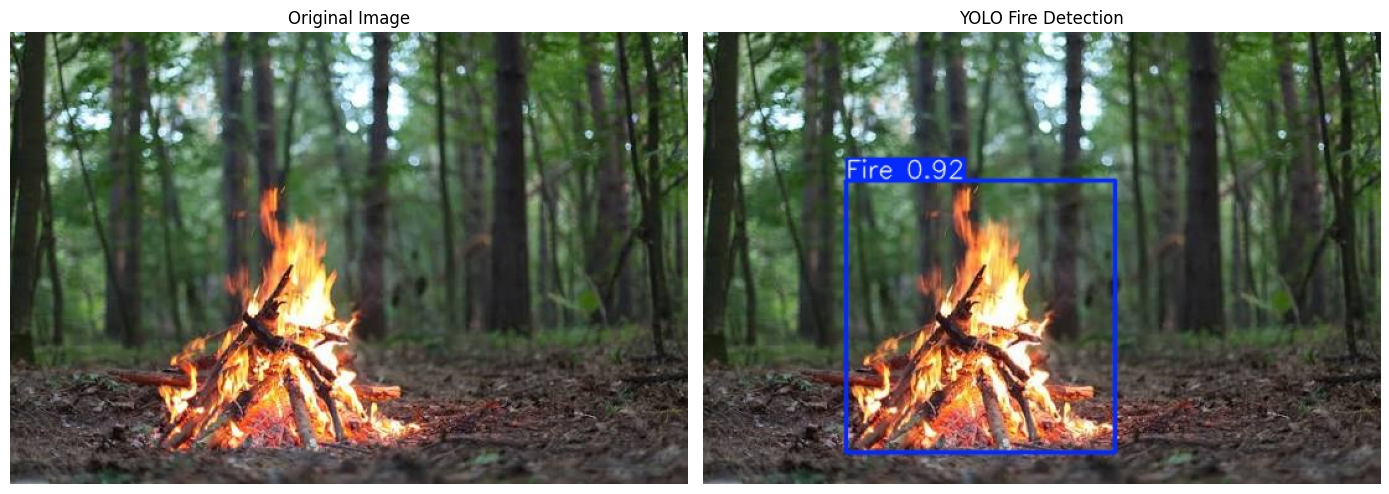

In [29]:
from pathlib import Path
from PIL import Image
from IPython.display import display
import matplotlib.pyplot as plt

original_path = Path("/content/drive/MyDrive/fire_smoke_demo/test.jpg")
predicted_path = Path(
    "/content/drive/MyDrive/FireSmokeYOLO/predictions/demo/test.jpg"
)

original_image = Image.open(original_path)
predicted_image = Image.open(predicted_path)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(predicted_image)
plt.title("YOLO Fire Detection")
plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
from pathlib import Path
from ultralytics import YOLO

BASELINE_WEIGHTS = Path(
    "/content/drive/MyDrive/FireSmokeYOLO/raw_runs/baseline/weights/best.pt"
)

print(BASELINE_WEIGHTS.exists())

True


## 10. Export Submission Package

In [24]:
archive_base = "/content/FireSmokeYOLO_Results"
shutil.make_archive(archive_base, "zip", PROJECT_ROOT)
print(f"Created {archive_base}.zip")

Created /content/FireSmokeYOLO_Results.zip
